In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder

from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import classification_report

# CHARGEMENT DES DONNÉES
df  = pd.read_csv("https://raw.githubusercontent.com/ilalangapp/rain_in_AUS/master/weatherAUS.csv")

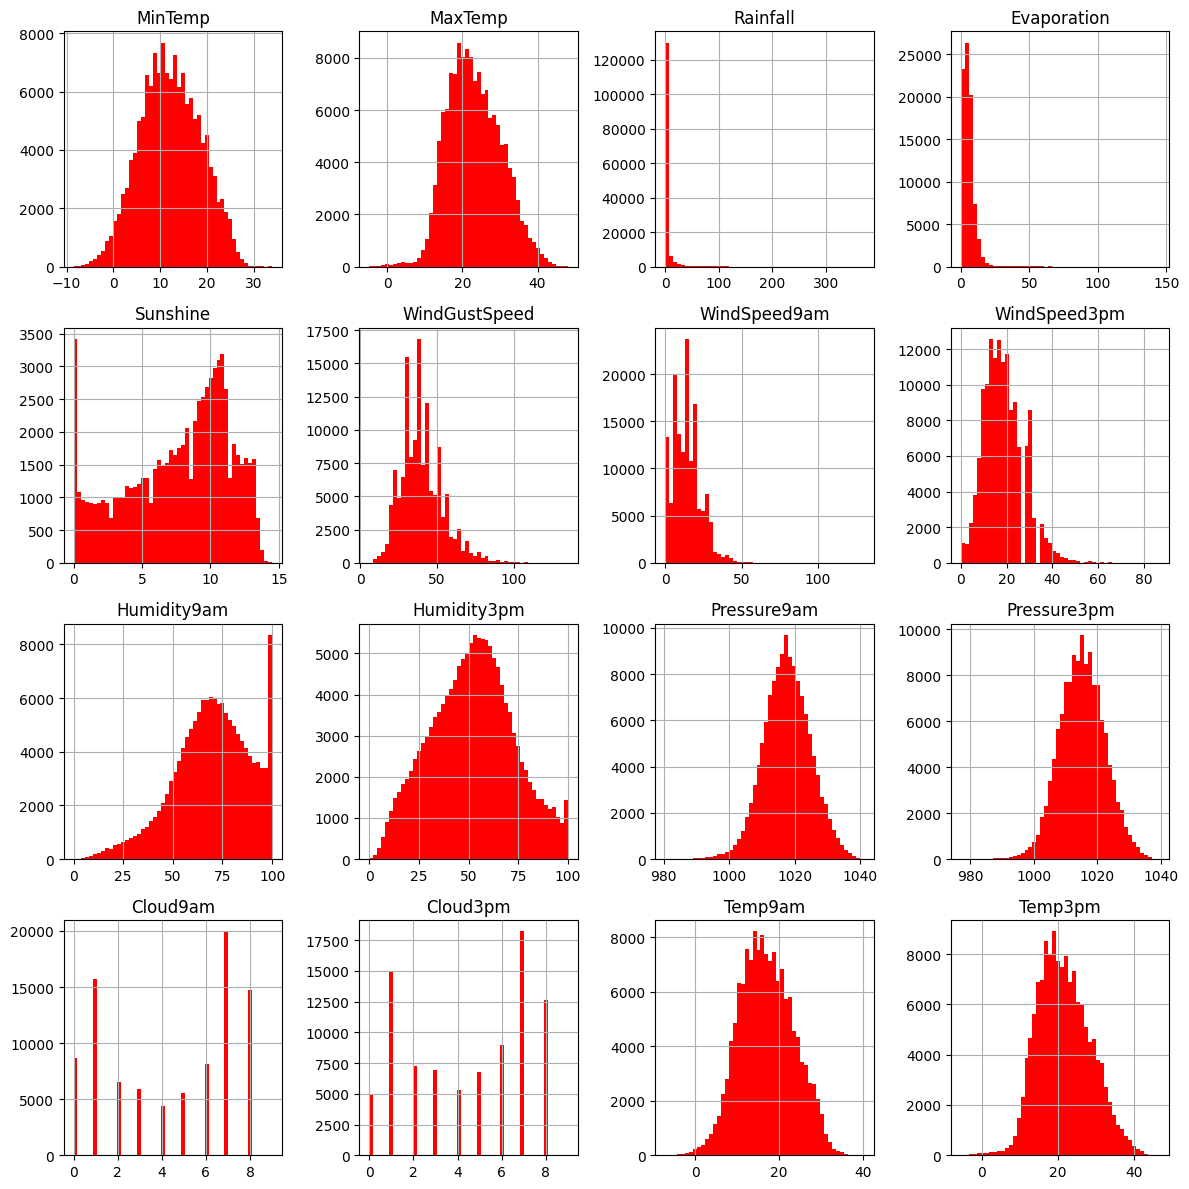

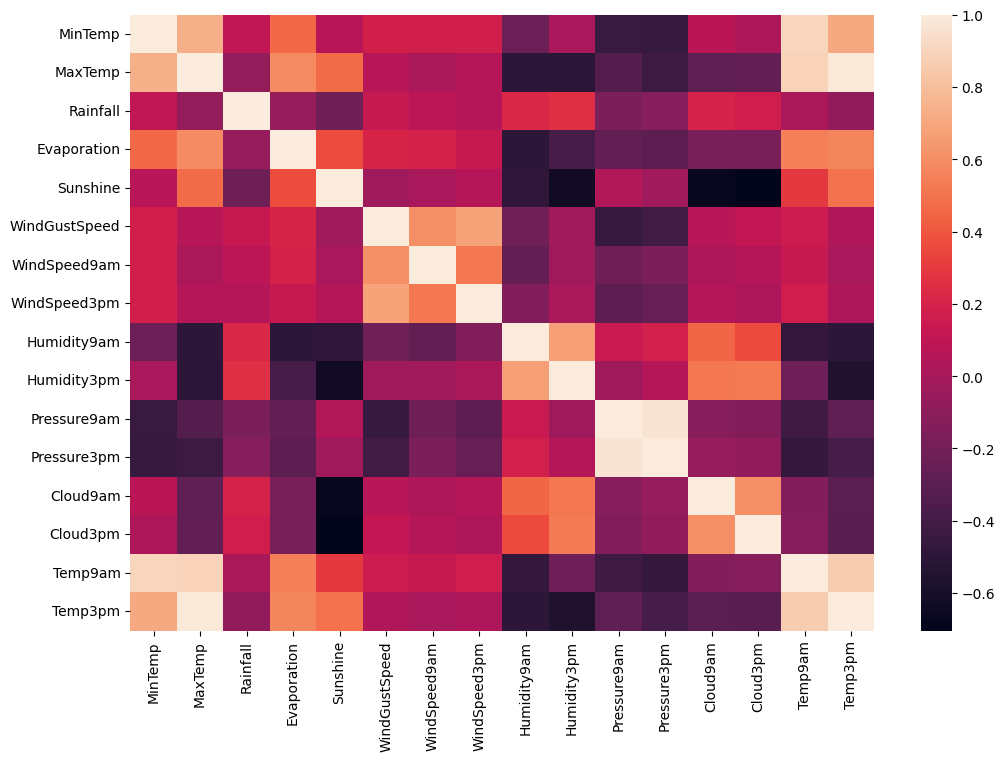

In [2]:
# EXPLORATION DES DONNÉES
# Récupération des variables numériques pour visualiser la distribution des variables
num_variables = df.select_dtypes(include="number")

# Génération des histogrammes
num_variables.hist(figsize=(12, 12), bins=50, color='red')
plt.tight_layout()
#plt.show()

# Visualisation de la corrélation des variables
plt.figure(figsize=(12, 8))
sns.heatmap(num_variables.corr())
plt.show()

In [3]:
# FEATURES ENGINEERING
# Extraction de la date
df['Date'] = pd.to_datetime(df['Date'])
df['Mois'] = df['Date'].dt.month
df_clean = df.drop(columns=['Date'])

# Calcul des variations de la journée
# Amplitude et Évolutions
df_clean['Amplitude_Temperature'] = df_clean['MaxTemp'] - df_clean['MinTemp']
df_clean['Evolution_Pression'] = df_clean['Pressure3pm'] - df_clean['Pressure9am']
df_clean['Evolution_Humidity'] = df_clean['Humidity3pm'] - df_clean['Humidity9am']


# NETTOYAGE DE LA CIBLE
df_clean['RainTomorrow'] = df_clean['RainTomorrow'].replace({"No": 0, "Yes": 1})

# Suppression des lignes où la réponse est vide
df_clean = df_clean.dropna(subset=['RainTomorrow'])

# SÉPARATION DES DONNÉES
X = df_clean.drop(columns=['RainTomorrow'])
y = df_clean['RainTomorrow']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# CONSTRUCTION DE LA PIPELINE
# Imputation
colonne_num = X_train.select_dtypes(include="number").columns
colonne_texte = X_train.select_dtypes(include="object").columns

imputer_nombres = SimpleImputer(strategy="mean")

# Préparation de la chaîne de montage pour le texte
pipeline_texte = Pipeline(steps=[
    ('most_frequent', SimpleImputer(strategy="most_frequent")),
    ('encoding', OneHotEncoder(drop = 'first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', imputer_nombres, colonne_num),
        ('cat', pipeline_texte, colonne_texte)
    ]
)

# EXÉCUTION DU NETTOYAGE
X_train_clean = preprocessor.fit_transform(X_train)
X_test_clean = preprocessor.transform(X_test)

/tmp/ipykernel_22/3277133170.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_clean['RainTomorrow'] = df_clean['RainTomorrow'].replace({"No": 0, "Yes": 1})


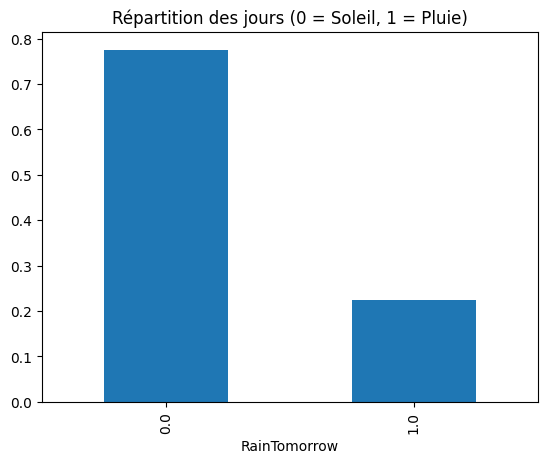

In [4]:
import matplotlib.pyplot as plt

# Répartition des classes
y_train.value_counts(normalize=True).plot(kind='bar', title='Répartition des jours (0 = Soleil, 1 = Pluie)')
plt.show()

# **Validation des modèles**

In [5]:
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as imbpipeline
from sklearn.model_selection import cross_val_score

# On définit les composants
smote = SMOTE(random_state=42)
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
knn = KNeighborsClassifier(n_neighbors=5, n_jobs=-1)

# On crée les Pipelines pour la Cross-Validation
pipeline_rf = imbpipeline(steps=[('smote', smote), ('model', rf)])
pipeline_knn = imbpipeline(steps=[('smote', smote), ('model', knn)])

print("Validation Croisée Random Forest")
scores_rf = cross_val_score(pipeline_rf, X_train_clean, y_train, cv=5, scoring='recall')
print(f"Scores Random Forest : {scores_rf}")
print(f"Moyenne Rappel RF : {scores_rf.mean():.4f}")

print("\nValidation Croisée KNN en cours")
scores_knn = cross_val_score(pipeline_knn, X_train_clean, y_train, cv=5, scoring='recall', verbose=2)
print(f"Scores KNN : {scores_knn}")
print(f"Moyenne Rappel KNN : {scores_knn.mean():.4f}")

Validation Croisée Random Forest
Scores Random Forest : [0.58037987 0.58840807 0.58664578 0.58065779 0.57372234]
Moyenne Rappel RF : 0.5820

Validation Croisée KNN en cours
[CV] END .................................................... total time= 2.8min
[CV] END .................................................... total time= 2.8min
[CV] END .................................................... total time= 2.8min
[CV] END .................................................... total time= 2.8min
[CV] END .................................................... total time= 2.7min
Scores KNN : [0.75386724 0.74995105 0.75347562 0.73884103 0.73526532]
Moyenne Rappel KNN : 0.7463


[Parallel(n_jobs=1)]: Done   5 out of   5 | elapsed: 13.9min finished


# **Tuning d’hyperparamètres**

In [6]:
from sklearn.model_selection import RandomizedSearchCV

print("Lancement du tuning : Random Forest...")

# Dictionnaire pour le Random Forest
parametres_rf_rapide = {
    'model__n_estimators': [50, 100],          # Maximum 100 arbres
    'model__max_depth': [10, 15],              
    'model__min_samples_split': [5, 10],       
    'model__min_samples_leaf': [2, 4]          
}

# Configuration du chercheur
chercheur_rf = RandomizedSearchCV(
    estimator=pipeline_rf,
    param_distributions=parametres_rf_rapide, 
    n_iter=3,                                  
    scoring='recall',                  
    cv=3,                                      # 3 plis de validation croisée
    random_state=42,
    n_jobs=-1,                                
    verbose=2                          
)

# Lancement de la recherche
chercheur_rf.fit(X_train_clean, y_train)

print("\n RÉSULTATS DU TUNING RANDOM FOREST : ")
print(f"Meilleurs réglages : {chercheur_rf.best_params_}")
print(f"Nouveau score de Rappel : {chercheur_rf.best_score_:.4f}")

Lancement du tuning : Random Forest...
Fitting 3 folds for each of 3 candidates, totalling 9 fits

 RÉSULTATS DU TUNING RANDOM FOREST : 
Meilleurs réglages : {'model__n_estimators': 100, 'model__min_samples_split': 5, 'model__min_samples_leaf': 4, 'model__max_depth': 10}
Nouveau score de Rappel : 0.6870


In [7]:
from sklearn.model_selection import RandomizedSearchCV

print("Lancement du tuning : KNN...")

# Dictionnaire  pour le KNN
parametres_knn_rapide = {
    'model__n_neighbors': [5, 9],            
    'model__weights': ['uniform', 'distance'], 
    'model__p': [2],                           # On  teste  la distance Euclidienne
}

# Configuration du chercheur
chercheur_knn = RandomizedSearchCV(
    estimator=pipeline_knn,             
    param_distributions=parametres_knn_rapide, 
    n_iter=2,                                 
    scoring='recall',                  
    cv=3,                                      # 3 plis de validation croisée
    random_state=42,
    n_jobs=-1,                         
    verbose=2                          
)

# Lancement de la recherche
chercheur_knn.fit(X_train_clean, y_train)

print("\n RÉSULTATS DU TUNING KNN : ")
print(f"Meilleurs réglages : {chercheur_knn.best_params_}")
print(f"Nouveau score de Rappel : {chercheur_knn.best_score_:.4f}")

Lancement du tuning : KNN...
Fitting 3 folds for each of 2 candidates, totalling 6 fits
[CV] END model__max_depth=10, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=50; total time= 1.1min
[CV] END model__max_depth=10, model__min_samples_leaf=4, model__min_samples_split=5, model__n_estimators=100; total time= 1.7min
[CV] END model__n_neighbors=5, model__p=2, model__weights=distance; total time=11.7min
[CV] END model__max_depth=10, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=50; total time= 1.1min
[CV] END model__max_depth=10, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=100; total time= 1.7min
[CV] END model__max_depth=10, model__min_samples_leaf=4, model__min_samples_split=5, model__n_estimators=100; total time=  41.6s
[CV] END model__n_neighbors=9, model__p=2, model__weights=distance; total time=11.8min

 RÉSULTATS DU TUNING KNN : 
Meilleurs réglages : {'model__weights': 'distance', 'model__p': 2,

In [8]:
import joblib

# On sauvegarde les deux chercheurs complets qui contiennent les meilleurs modèles
print(" Sauvegarde des modèles en cours...")

# Sauvegarde du Random Forest
joblib.dump(chercheur_rf, 'meilleur_rf_calibre.pkl')

# Sauvegarde du KNN
joblib.dump(chercheur_knn, 'meilleur_knn_calibre.pkl')

print(" Modèles sauvegardés avec succès sur le disque ")

 Sauvegarde des modèles en cours...
 Modèles sauvegardés avec succès sur le disque 


# **Interprétation des modèles Random Forest et KNN**

In [9]:
# COMPARAISON ET RAPPORTS FINAUX (BRUT VS OPTIMISÉ)
from sklearn.metrics import classification_report
from sklearn.metrics import roc_auc_score

# On prépare les données d'entraînement finales avec SMOTE pour les modèles BRUTS
X_train_smote, y_train_smote = smote.fit_resample(X_train_clean, y_train)

# --- A. RANDOM FOREST ---
# On entraîne le modèle BRUT 
rf.fit(X_train_smote, y_train_smote)
pred_rf_brut = rf.predict(X_test_clean)

# On utilise directement le chercheur pour prédire avec le modèle OPTIMISÉ 
pred_rf_calibre = chercheur_rf.predict(X_test_clean)

# --- B. KNN ---
# On entraîne le modèle BRUT
knn.fit(X_train_smote, y_train_smote)
pred_knn_brut = knn.predict(X_test_clean)

# On utilise directement le chercheur pour prédire avec le modèle OPTIMISÉ
pred_knn_calibre = chercheur_knn.predict(X_test_clean)

# --- AFFICHAGE DES COMPARAISONS ---
print(" RANDOM FOREST : BRUT vs OPTIMISÉ ")
print("\n RAPPORT BRUT ")
print(classification_report(y_test, pred_rf_brut))
print("\n RAPPORT OPTIMISÉ (Après Tuning)")
print(classification_report(y_test, pred_rf_calibre))

print("\n\n KNN : BRUT vs OPTIMISÉ")
print("\n RAPPORT BRUT ")
print(classification_report(y_test, pred_knn_brut))
print("\n RAPPORT OPTIMISÉ (Après Tuning)")
print(classification_report(y_test, pred_knn_calibre))

# Calcul des AUC avec les probabilités des modèles optimisés
print(f"ROC-AUC Final Random Forest : {roc_auc_score(y_test, chercheur_rf.predict_proba(X_test_clean)[:, 1]):.4f}")
print(f"ROC-AUC Final KNN : {roc_auc_score(y_test, chercheur_knn.predict_proba(X_test_clean)[:, 1]):.4f}")

[CV] END model__max_depth=10, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=100; total time= 1.4min
[CV] END model__max_depth=10, model__min_samples_leaf=4, model__min_samples_split=5, model__n_estimators=100; total time= 1.6min
[CV] END model__n_neighbors=5, model__p=2, model__weights=distance; total time=11.7min
[CV] END model__n_neighbors=9, model__p=2, model__weights=distance; total time= 6.0min
[CV] END model__max_depth=10, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=50; total time= 1.1min
[CV] END model__max_depth=10, model__min_samples_leaf=2, model__min_samples_split=5, model__n_estimators=100; total time= 1.7min
[CV] END model__n_neighbors=5, model__p=2, model__weights=distance; total time=11.7min
[CV] END model__n_neighbors=9, model__p=2, model__weights=distance; total time= 6.0min
 RANDOM FOREST : BRUT vs OPTIMISÉ 

 RAPPORT BRUT 
              precision    recall  f1-score   support

         0.0       0.89      0.

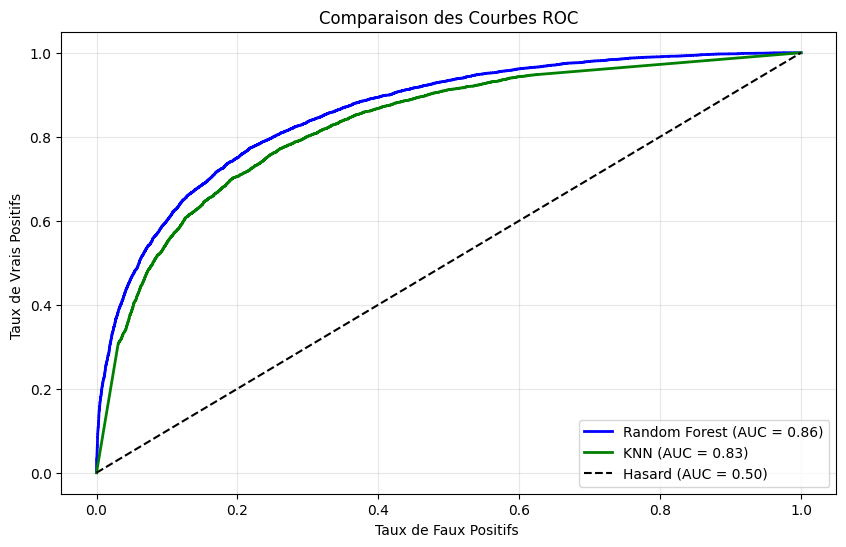

In [10]:
from sklearn.metrics import roc_curve, roc_auc_score
import matplotlib.pyplot as plt

# On récupère les probabilités avec les modèles optimisés (les chercheurs)
# On garde la 2ème colonne qui est la probabilité de PLUIE
probs_rf = chercheur_rf.predict_proba(X_test_clean)[:, 1]
probs_knn = chercheur_knn.predict_proba(X_test_clean)[:, 1]

# On calcule les points de la courbe 
fpr_rf, tpr_rf, _ = roc_curve(y_test, probs_rf)
fpr_knn, tpr_knn, _ = roc_curve(y_test, probs_knn)

# On calcule le score AUC final
auc_rf = roc_auc_score(y_test, probs_rf)
auc_knn = roc_auc_score(y_test, probs_knn)

# Visualisation
plt.figure(figsize=(10, 6))
plt.plot(fpr_rf, tpr_rf, label=f'Random Forest (AUC = {auc_rf:.2f})', color='blue', lw=2)
plt.plot(fpr_knn, tpr_knn, label=f'KNN (AUC = {auc_knn:.2f})', color='green', lw=2)

# La ligne de base (le hasard : pile ou face)
plt.plot([0, 1], [0, 1], 'k--', label='Hasard (AUC = 0.50)')

plt.xlabel('Taux de Faux Positifs ')
plt.ylabel('Taux de Vrais Positifs ')
plt.title('Comparaison des Courbes ROC')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

/tmp/ipykernel_22/2323250078.py:20: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Variable', data=df_importances_rf.head(10), palette='viridis')


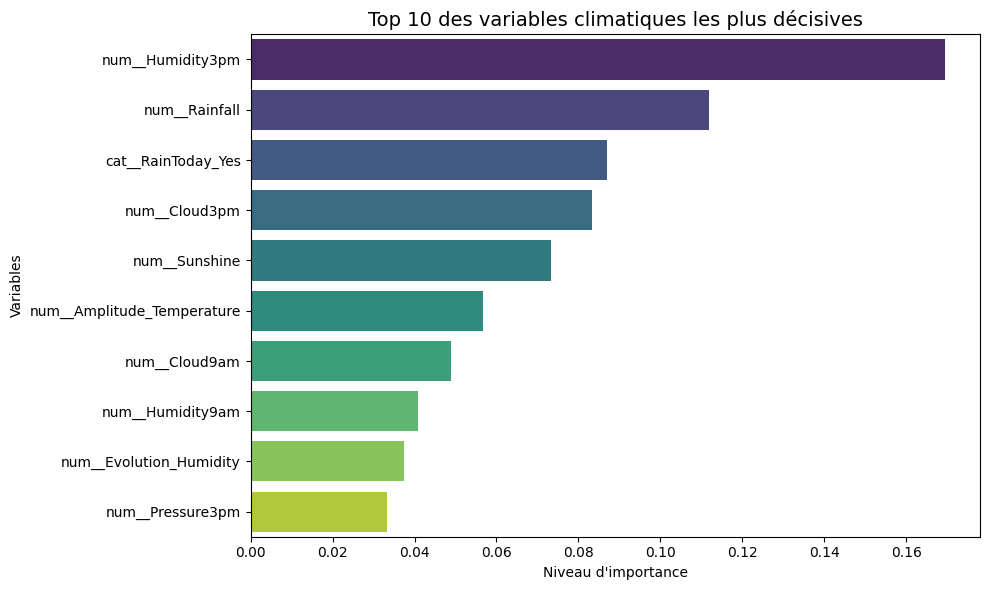

In [11]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# RANDOM FOREST
# On récupère le modèle final du Random Search
meilleur_modele_rf = chercheur_rf.best_estimator_.named_steps['model']

# On récupère les importances calculées par la forêt
importances_rf = meilleur_modele_rf.feature_importances_

# On crée un tableau pour que ce soit lisible 
df_importances_rf = pd.DataFrame({
    'Variable': preprocessor.get_feature_names_out(),
    'Importance': importances_rf
}).sort_values(by='Importance', ascending=False)

# Graphique à barres 
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Variable', data=df_importances_rf.head(10), palette='viridis')
plt.title("Top 10 des variables climatiques les plus décisives", fontsize=14)
plt.xlabel("Niveau d'importance")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

In [12]:
import joblib

chercheur_knn = joblib.load('meilleur_knn_calibre.pkl')
chercheur_rf = joblib.load('meilleur_rf_calibre.pkl')

Création de l'échantillon pour le KNN...
Calcul de l'importance en cours ...


/tmp/ipykernel_22/2473208462.py:52: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Variable', data=df_importances_knn.head(10), palette='viridis')


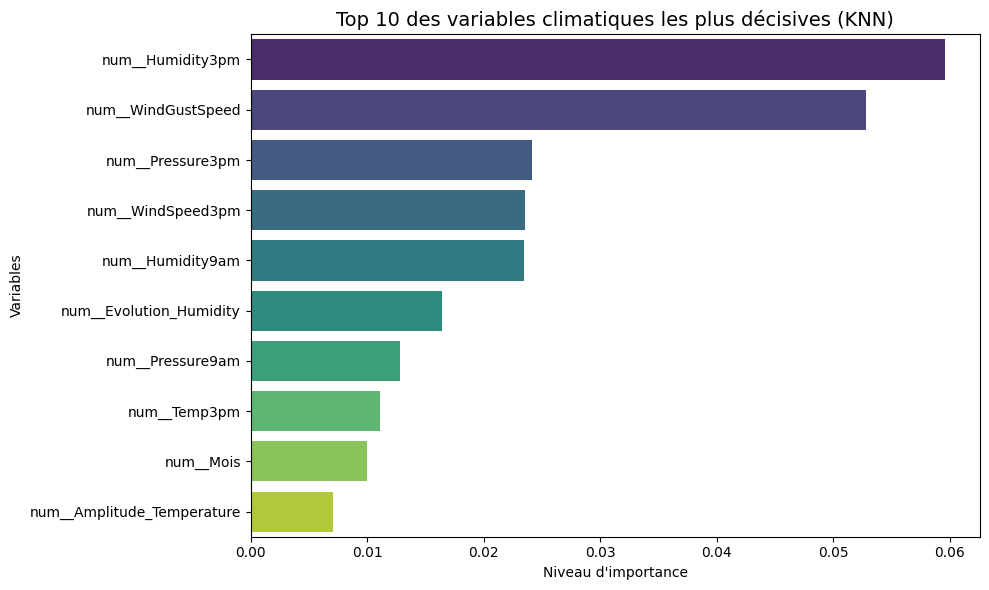

In [13]:
from sklearn.inspection import permutation_importance
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("Création de l'échantillon pour le KNN...")

# On récupère le modèle KNN final
meilleur_modele_knn = chercheur_knn.best_estimator_ 

# On génère les indices pour 10% des données de test
np.random.seed(42)
taille_echantillon = int(0.1 * X_test_clean.shape[0])
indices = np.random.choice(X_test_clean.shape[0], size=taille_echantillon, replace=False)

# On extrait l'échantillon et on le convertit en array 
import scipy.sparse
if scipy.sparse.issparse(X_test_clean):
    X_test_sample = X_test_clean[indices].toarray()
else:
    X_test_sample = X_test_clean[indices]
    
# On gère y_test selon qu'il soit un objet pandas (Series) ou un numpy array
if isinstance(y_test, (pd.Series, pd.DataFrame)):
    y_test_sample = y_test.iloc[indices]
else:
    y_test_sample = y_test[indices]

# On calcule l'importance par permutation  sur l'échantillon 
print("Calcul de l'importance en cours ...")
resultat_knn = permutation_importance(
    meilleur_modele_knn, 
    X_test_sample, 
    y_test_sample, 
    n_repeats=4, 
    random_state=42, 
    n_jobs=-1
)

# 5. On extrait les scores d'importance
importances_knn = resultat_knn.importances_mean

# 6. On crée le tableau pour l'affichage
df_importances_knn = pd.DataFrame({
    'Variable': preprocessor.get_feature_names_out(),
    'Importance': importances_knn
}).sort_values(by='Importance', ascending=False)

# 7. Graphique Barplot 
plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Variable', data=df_importances_knn.head(10), palette='viridis')
plt.title("Top 10 des variables climatiques les plus décisives (KNN)", fontsize=14)
plt.xlabel("Niveau d'importance")
plt.ylabel("Variables")
plt.tight_layout()
plt.show()

# **Matrice de confusion**

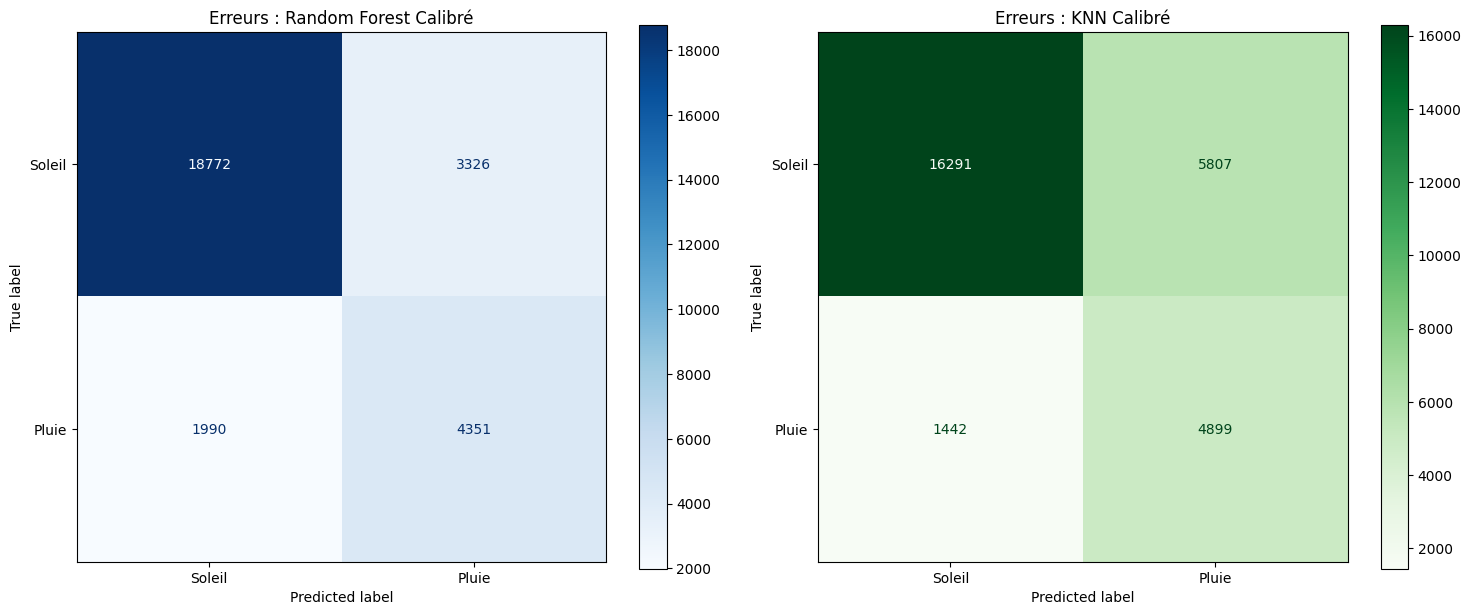

In [14]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Matrice pour Random Forest Calibré
cm_rf = confusion_matrix(y_test, pred_rf_calibre)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=['Soleil', 'Pluie'])
disp_rf.plot(cmap='Blues', ax=ax[0], values_format='d')
ax[0].set_title("Erreurs : Random Forest Calibré")

# Matrice pour KNN Calibré
cm_knn = confusion_matrix(y_test, pred_knn_calibre)
disp_knn = ConfusionMatrixDisplay(confusion_matrix=cm_knn, display_labels=['Soleil', 'Pluie'])
disp_knn.plot(cmap='Greens', ax=ax[1], values_format='d')
ax[1].set_title("Erreurs : KNN Calibré")

plt.tight_layout()
plt.show()

Analyse de l'Humidité à 15h selon le type d'erreur :
Resultat
Correct                         49.346915
Faux Négatif (Raté)             50.839750
Faux Positif (Fausse Alerte)    67.287874
Name: Humidity3pm, dtype: float64


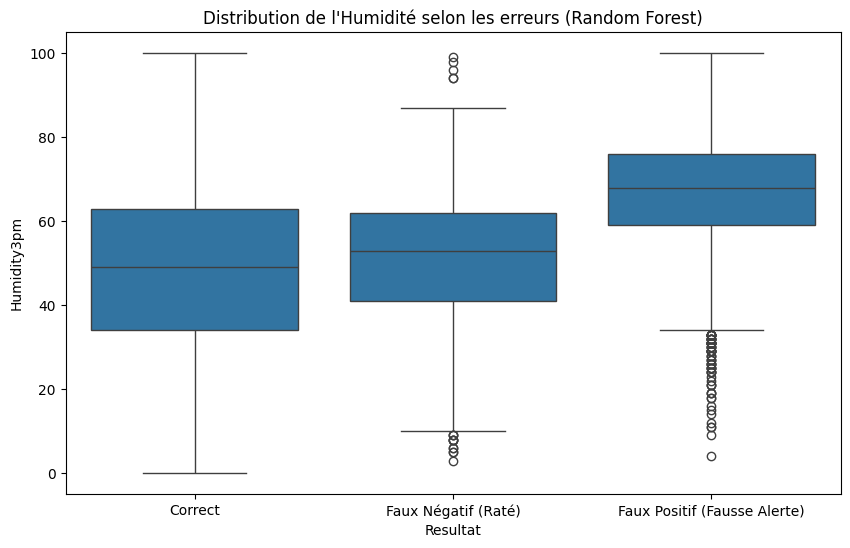

In [15]:
# On crée un petit tableau avec les prédictions et une variable clé 
analyse_erreurs = X_test.copy()
analyse_erreurs['Vrai_Label'] = y_test.values
analyse_erreurs['Prediction'] = pred_rf_calibre

# On crée des catégories pour comparer
def type_erreur(row):
    if row['Vrai_Label'] == row['Prediction']:
        return 'Correct'
    elif row['Vrai_Label'] == 1 and row['Prediction'] == 0:
        return 'Faux Négatif (Raté)'
    else:
        return 'Faux Positif (Fausse Alerte)'

analyse_erreurs['Resultat'] = analyse_erreurs.apply(type_erreur, axis=1)

# On regarde l'humidité moyenne pour chaque catégorie
print("Analyse de l'Humidité à 15h selon le type d'erreur :")
print(analyse_erreurs.groupby('Resultat')['Humidity3pm'].mean())

# Visualisation
plt.figure(figsize=(10, 6))
sns.boxplot(x='Resultat', y='Humidity3pm', data=analyse_erreurs)
plt.title("Distribution de l'Humidité selon les erreurs (Random Forest)")
plt.show()

Analyse de l'Humidité à 15h selon le type d'erreur (KNN) :
Resultat
Correct                         49.319262
Faux Négatif (Raté)             50.276748
Faux Positif (Fausse Alerte)    60.043293
Name: Humidity3pm, dtype: float64


/tmp/ipykernel_22/118345132.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Resultat', y='Humidity3pm', data=analyse_erreurs_knn, palette='Set2')


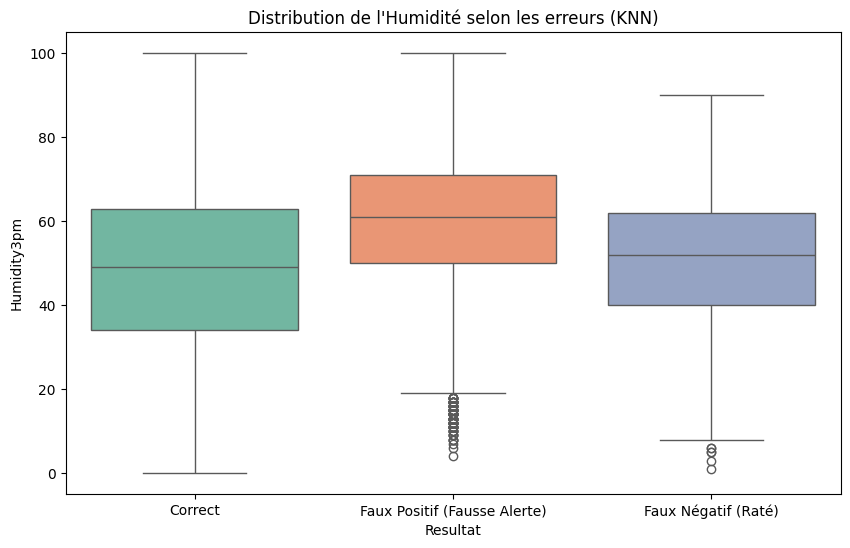

In [16]:
# ANALYSE DES ERREURS : KNN

# On crée un tableau avec les prédictions du KNN
analyse_erreurs_knn = X_test.copy()
analyse_erreurs_knn['Vrai_Label'] = y_test.values
analyse_erreurs_knn['Prediction_KNN'] = pred_knn_calibre

# Fonction pour catégoriser les erreurs
def type_erreur_knn(row):
    if row['Vrai_Label'] == row['Prediction_KNN']:
        return 'Correct'
    elif row['Vrai_Label'] == 1 and row['Prediction_KNN'] == 0:
        return 'Faux Négatif (Raté)'
    else:
        return 'Faux Positif (Fausse Alerte)'

analyse_erreurs_knn['Resultat'] = analyse_erreurs_knn.apply(type_erreur_knn, axis=1)

# On regarde l'humidité moyenne pour chaque catégorie (KNN)
print("Analyse de l'Humidité à 15h selon le type d'erreur (KNN) :")
print(analyse_erreurs_knn.groupby('Resultat')['Humidity3pm'].mean())

# Visualisation (Boxplot)
plt.figure(figsize=(10, 6))
sns.boxplot(x='Resultat', y='Humidity3pm', data=analyse_erreurs_knn, palette='Set2')
plt.title("Distribution de l'Humidité selon les erreurs (KNN)")
plt.show()

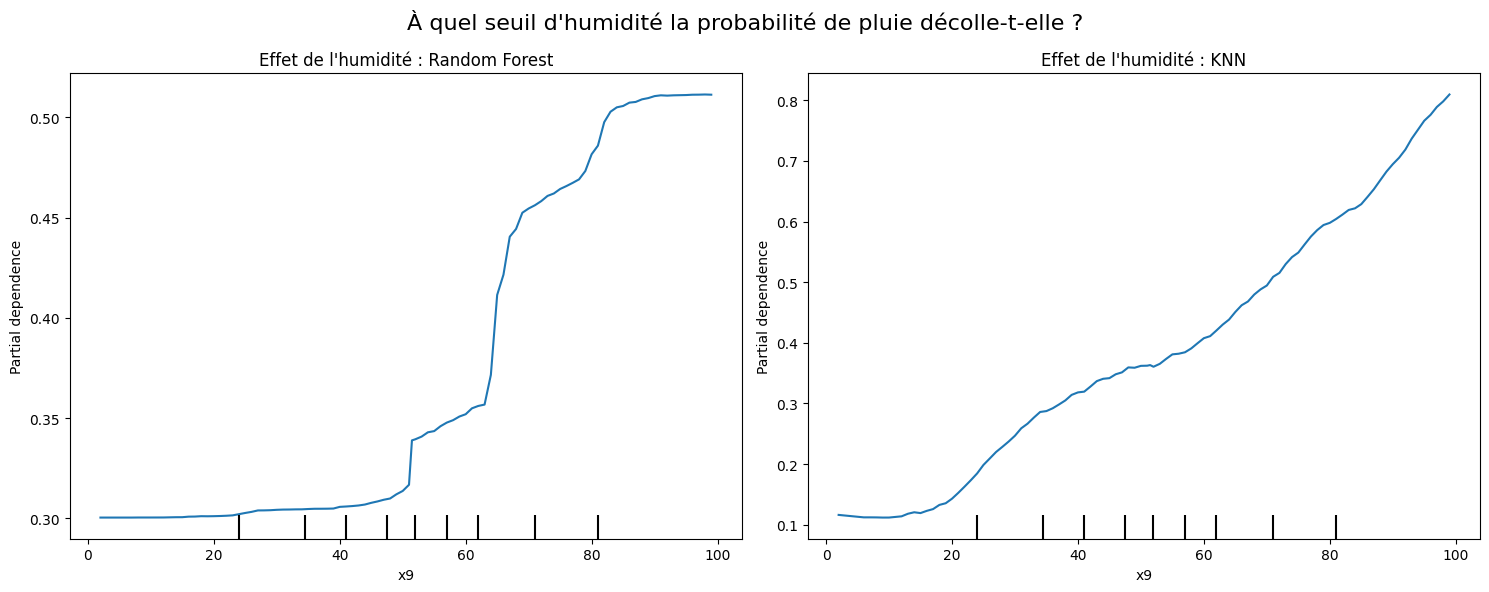

In [17]:
from sklearn.inspection import PartialDependenceDisplay
import scipy.sparse
import matplotlib.pyplot as plt

# On trouve l'index exact de la colonne Humidité générée par le preprocessor
noms_colonnes = list(preprocessor.get_feature_names_out())
idx_humidite = [i for i, col in enumerate(noms_colonnes) if 'Humidity3pm' in col][0]

# Conversion en tableau dense si nécessaire
if scipy.sparse.issparse(X_test_clean):
    X_test_dense = X_test_clean.toarray()
else:
    X_test_dense = X_test_clean

# On prend les 500 premières lignes
X_test_tres_petit = X_test_dense[:500]

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

# Courbes avec le petit échantillon 
PartialDependenceDisplay.from_estimator(chercheur_rf.best_estimator_, X_test_tres_petit, [idx_humidite], ax=ax[0])
ax[0].set_title("Effet de l'humidité : Random Forest")

PartialDependenceDisplay.from_estimator(chercheur_knn.best_estimator_, X_test_tres_petit, [idx_humidite], ax=ax[1])
ax[1].set_title("Effet de l'humidité : KNN")

plt.suptitle("À quel seuil d'humidité la probabilité de pluie décolle-t-elle ?", fontsize=16)
plt.tight_layout()
plt.show()